In [117]:
!pip install arxiv
import arxiv
import pandas as pd

# Initializing variables not shown in the snippet so the code runs successfully
category_mapping = {}
papers_data = []

# --- Code from your screenshot starts here ---

client = arxiv.Client(
    page_size = 5000,
    delay_seconds = 10.0,
    num_retries = 5
)

csv_filename = "arxiv_dataset.csv"
search = arxiv.Search(
    query="cat:cs.*",
    sort_by=arxiv.SortCriterion.SubmittedDate,
    max_results=2000
)

try:
    for result in client.results(search):
        paper_info = {
            "Title": result.title,
            "Category": result.primary_category,
            "Category Description": category_mapping.get(result.primary_category, "Unknown Category"),
            "Published": result.published.strftime("%Y-%m-%d"),  # Format date
            "Summary": result.summary
        }
        papers_data.append(paper_info)
        if len(papers_data) % 50 == 0:
            print(len(papers_data))
except Exception as e:
    print(e)
finally:
    df = pd.DataFrame(papers_data)
    df.to_csv(csv_filename, index=False)
    print(f"Saved {len(df)} papers in {csv_filename}")

50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500
1550
1600
1650
1700
1750
1800
1850
1900
1950
2000
Saved 2000 papers in arxiv_dataset.csv


In [118]:
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
import torch

# Using a smaller Qwen model to mitigate OutOfMemoryError
model_id = "Qwen/Qwen1.5-0.5B-Chat"

# Select device automatically
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
).to(device)

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0 if device == "cuda" else -1
)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [119]:
from transformers import pipeline

generation_pipeline = pipeline(
    task="text-generation",
    model=model,
    tokenizer=tokenizer
)

generation_pipeline("Hello what are you?", max_new_tokens=25)

Both `max_new_tokens` (=25) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'Hello what are you?'}]

In [120]:
# Batch generation example

prompts = [
    "Hello what are you?",
    "Explain machine learning in one sentence.",
    "What is the capital of Bangladesh?",
    "Give a short definition of artificial intelligence."
]

outputs = generation_pipeline(prompts, max_new_tokens=25)

for i, output in enumerate(outputs):
    print(f"Prompt {i+1}: {prompts[i]}")
    print(f"Response: {output[0]['generated_text']}")
    print("-" * 40)

Both `max_new_tokens` (=25) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=25) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=25) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=25) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt 1: Hello what are you?
Response: Hello what are you?
----------------------------------------
Prompt 2: Explain machine learning in one sentence.
Response: Explain machine learning in one sentence.
----------------------------------------
Prompt 3: What is the capital of Bangladesh?
Response: What is the capital of Bangladesh?
----------------------------------------
Prompt 4: Give a short definition of artificial intelligence.
Response: Give a short definition of artificial intelligence.
----------------------------------------


In [121]:
import torch

input_prompt = [
    "Hello how are you?",
    "The capital of Bangladesh is Noakhali?"
]

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenized = tokenizer(
    input_prompt,
    return_tensors="pt",
    padding=True
).to(device)

print(tokenized["input_ids"].shape)

torch.Size([2, 9])


In [122]:
tokenized["input_ids"] # error dile padding enable kora lagto but luckily its sorted

tensor([[  9707,   1246,    525,    498,     30, 151643, 151643, 151643, 151643],
        [   785,   6722,    315,  38501,    374,   2308,  21758,   7956,     30]],
       device='cuda:0')

In [123]:
tokenizer.batch_decode(tokenized["input_ids"])

['Hello how are you?<|endoftext|><|endoftext|><|endoftext|><|endoftext|>',
 'The capital of Bangladesh is Noakhali?']

In [124]:
tokenized["attention_mask"]

tensor([[1, 1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0')

Chat Templates

In [125]:
prompt = [
    {
        "role": "system",
        "content": "You are a smart AI assistant who speaks like a pirate."
    },
    {
        "role": "user",
        "content": "Where does the sun rise?"
    },
    {
        "role": "assistant",
        "content": "Aye Aye"
    }
]

tokenizer.pad_token = tokenizer.eos_token

tokenized = tokenizer.apply_chat_template(
    prompt,
    continue_final_message=True,
    tokenize=True,
    padding=True,
    return_tensors="pt"
)

print(tokenized)

{'input_ids': tensor([[151644,   8948,    198,   2610,    525,    264,   7785,  15235,  17847,
            879,  21191,   1075,    264,  53966,     13, 151645,    198, 151644,
            872,    198,   9064,   1558,    279,   7015,  10000,     30, 151645,
            198, 151644,  77091,    198,     32,   9011,    362,   9011]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


In [126]:
device = "cuda" if torch.cuda.is_available() else "cpu"

out = model.generate(
    **tokenized.to(device),
    max_new_tokens=40
)

In [127]:
out

tensor([[151644,   8948,    198,   2610,    525,    264,   7785,  15235,  17847,
            879,  21191,   1075,    264,  53966,     13, 151645,    198, 151644,
            872,    198,   9064,   1558,    279,   7015,  10000,     30, 151645,
            198, 151644,  77091,    198,     32,   9011,    362,   9011,      0,
            576,   7015,  37168,    518,    911,    220,     18,     25,     15,
             15,    281,    744,     13,   2205,    882,    389,    279,  11580,
           9237,     11,    892,    374,  13187,    220,     17,     19,   4115,
           8305,    315,    279,   1482,    882,    389,    279,  17330,     13,
         151645]], device='cuda:0')

In [128]:
decoded=tokenizer.batch_decode(out)
print(decoded[0])

<|im_start|>system
You are a smart AI assistant who speaks like a pirate.<|im_end|>
<|im_start|>user
Where does the sun rise?<|im_end|>
<|im_start|>assistant
Aye Aye! The sun rises at about 3:00 p.m. local time on the planet Earth, which is approximately 24 hours ahead of the current time on the Moon.<|im_end|>


In [129]:
import pandas as pd
df=pd.read_csv("arxiv_dataset.csv")
df.head()


,Title,Category,Category Description,Published,Summary
0,Scale Space Diffusion,cs.CV,Unknown Category,2026-03-09,"Diffusion models degrade images through noise,..."
1,FVG-PT: Adaptive Foreground View-Guided Prompt...,cs.CV,Unknown Category,2026-03-09,CLIP-based prompt tuning enables pretrained Vi...
2,Impermanent: A Live Benchmark for Temporal Gen...,cs.LG,Unknown Category,2026-03-09,Recent advances in time-series forecasting inc...
3,Agentic Critical Training,cs.AI,Unknown Category,2026-03-09,Training large language models (LLMs) as auton...
4,Evaluating Financial Intelligence in Large Lan...,cs.AI,Unknown Category,2026-03-09,Large language models are increasingly used fo...


In [130]:
device = "cuda" if torch.cuda.is_available() else "cpu"

predictions = []

for _, row in df.head(5).iterrows():

    messages = [
        {
            "role": "system",
            "content": """You are an AI system that reads the title and summary of a research paper and classifies which area of computer science the paper belongs.

No explanation required, you must choose from the following classes:
Labeled Category: Machine Learning
or Labeled Category: Computer Vision and Pattern Recognition
or Labeled Category: Computation and Language (Natural Language Processing)
or Labeled Category: Robotics
or Labeled Category: Cryptography and Security
or Labeled Category: Artificial Intelligence.

Ensure your output is from the above list only."""
        },
        {
            "role": "user",
            "content": f"Title: {row['Title']}\nSummary: {row['Summary']}"
        },
        {
            "role": "assistant",
            "content": "Labeled Category:"
        }
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        continue_final_message=True,
        return_tensors="pt"
    ).to(device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=20
    )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    prediction = text.split("Labeled Category:")[-1].strip()

    predictions.append(prediction)

print(predictions)

['Computer Vision and Pattern Recognition', 'Computer Vision and Pattern Recognition', 'Computer Vision and Pattern Recognition', 'Computer Vision and Pattern Recognition', 'Financial Intelligence']


In [131]:
import torch
import pandas as pd
from sklearn.model_selection import train_test_split

In [132]:
train_df, test_df = train_test_split(
    df,
    test_size=200,
    random_state=42
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 1800
Test size: 200


In [133]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [134]:
label_map = {
    "cs.CV": "Computer Vision and Pattern Recognition",
    "cs.LG": "Computation and Language (Natural Language Processing)",
    "cs.AI": "Artificial Intelligence",
    "cs.RO": "Robotics",
    "cs.CR": "Cryptography and Security",
    "cs.IR": "Machine Learning"
}

df["mapped_label"] = df["Category"].map(label_map)

In [135]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=200,
    random_state=42
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 1800
Test size: 200


In [136]:
predictions = []
labels = []

for _, row in test_df.iterrows():

    messages = [
        {
            "role": "system",
            "content": """You are an AI system that reads the title and summary of a research paper and classifies which area of computer science the paper belongs.

Choose ONLY from:

Labeled Category: Machine Learning
Labeled Category: Computer Vision and Pattern Recognition
Labeled Category: Computation and Language (Natural Language Processing)
Labeled Category: Robotics
Labeled Category: Cryptography and Security
Labeled Category: Artificial Intelligence"""
        },
        {
            "role": "user",
            "content": f"Title: {row['Title']}\nSummary: {row['Summary']}"
        },
        {
            "role": "assistant",
            "content": "Labeled Category:"
        }
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        continue_final_message=True,
        return_tensors="pt"
    ).to(device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=15
    )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    pred = text.split("Labeled Category:")[-1].strip()

    predictions.append(pred)
    labels.append(row["mapped_label"])

In [ ]:
results_df = pd.DataFrame({
    "predictions": predictions,
    "labels": labels
})

print(results_df.head(10))

In [ ]:
correct = sum(p == l for p, l in zip(predictions, labels))

accuracy = correct / len(labels)

print("Number of test examples:", len(labels))
print("accuracy =", round(accuracy,3))

Time for Fine Tuning

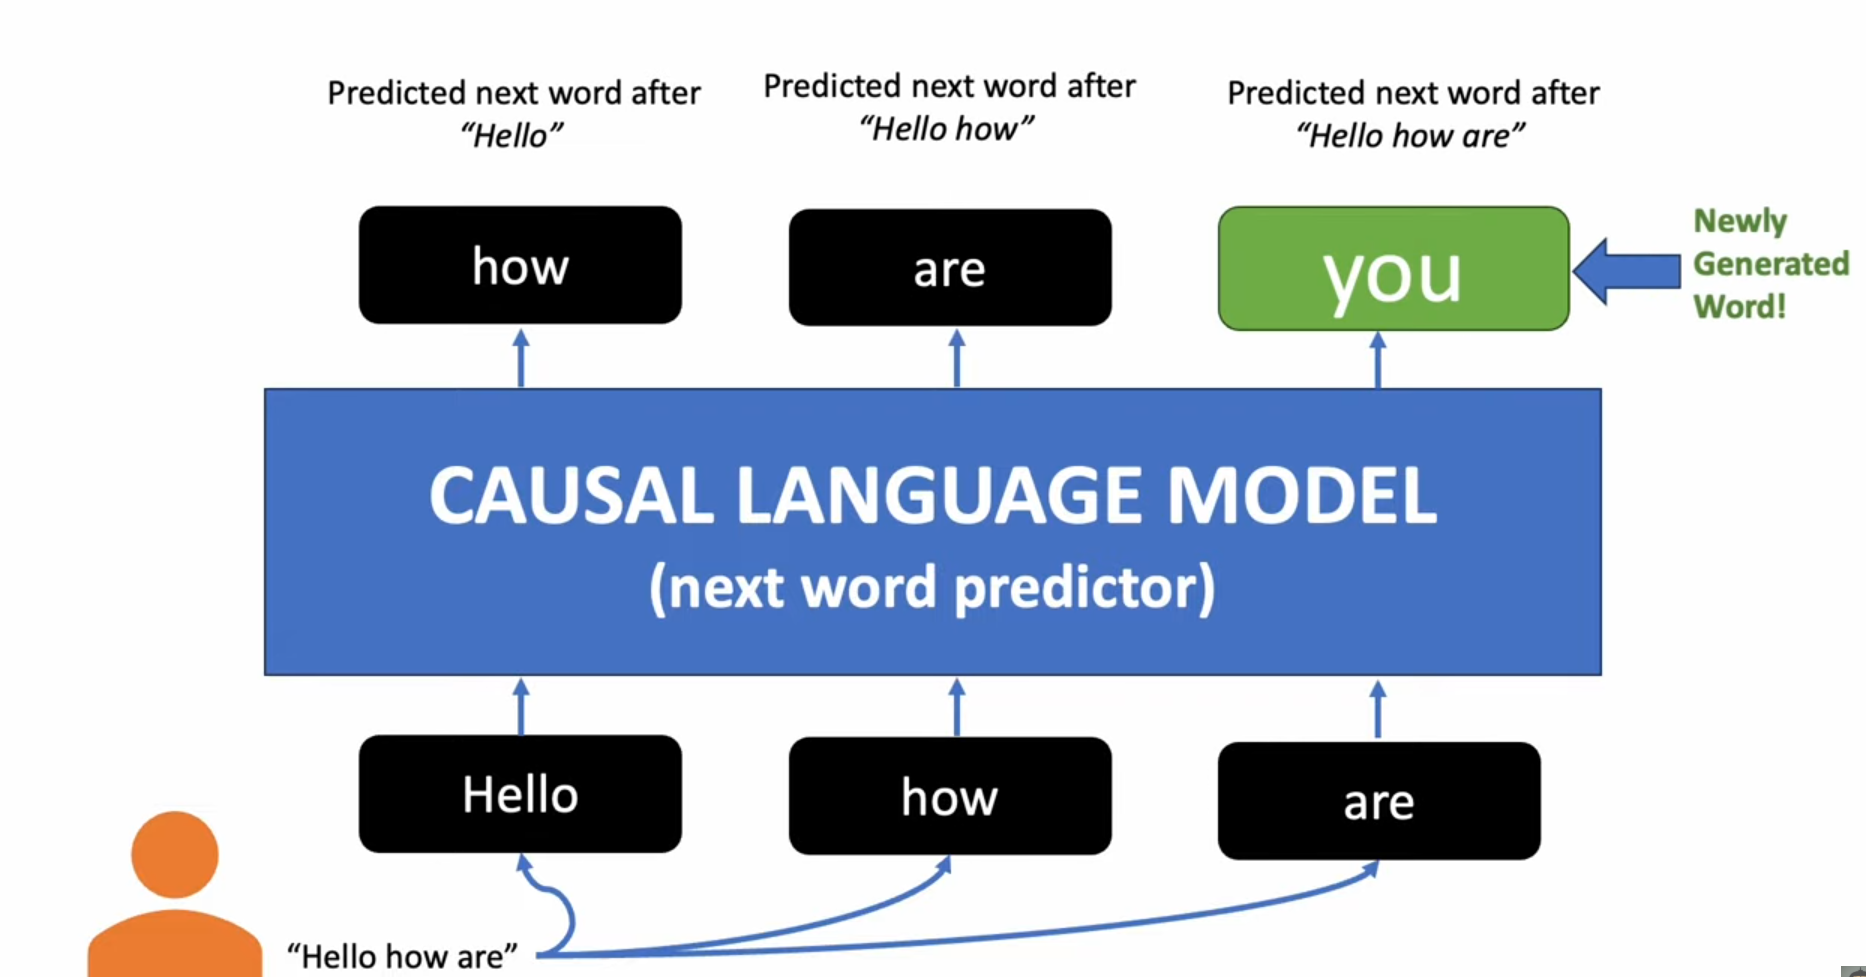

In [ ]:
text = "Hello how are"

input_ids = tokenizer(
    [text],
    return_tensors="pt"
)["input_ids"].to(device)

out = model(input_ids=input_ids)

In [ ]:
out

In [ ]:
input_ids

In [ ]:
# logits for next token prediction
logits = out.logits

print("Input shape:", input_ids.shape)
print("Logits shape:", logits.shape)

In [ ]:
out.logits.argmax(axis=-1)

In [ ]:
tokenizer.decode(out.logits.argmax(axis=-1)[0,-1])

In [ ]:
import torch.nn as nn
probablity_dist=nn.Softmax()(out.logits[0,-1])

In [ ]:
probablity_dist[498]

Training on Sequence

In [ ]:
sentence = ["Soon you'll see more of Shakhoyat Rahman"]

tokenized = tokenizer(sentence, return_tensors="pt")["input_ids"]

print(tokenized)

print(tokenizer.batch_decode(tokenized))

In [ ]:
input_ids = tokenized[:, :-1]   # (start) to (end - 1)
target_ids = tokenized[:, 1:]   # (start + 1) to (end)

print(input_ids)
print(target_ids)

Chat Template Idea

In [ ]:
question ="Capital of Noakhali?"
answer="Noakhali"
prompt=[
    {"role":"user","content":"Capital of Noakhali?"},
    {"role":"assistant","content":"Noakhali"}
]
answer="Noakhali"
chat_template = tokenizer.apply_chat_template(prompt, continue_final_message=True,tokenize=False)
print(chat_template)

In [ ]:
print(tokenizer.convert_ids_to_tokens(266))
print(tokenizer.convert_ids_to_tokens(97276))

Tokenize the answer

In [ ]:
labels_tokenized = tokenizer(
    [" " + answer],
    add_special_tokens=False,
    return_tensors="pt"
)["input_ids"]

print(labels_tokenized)

Add EOS + Padding to Match Target Length

In [ ]:
labels_tokenized = tokenizer(
    [" " + answer + tokenizer.eos_token],
    add_special_tokens=False,
    return_tensors="pt",
    padding="max_length",
    max_length=target_ids.shape[1]
)["input_ids"]

print(labels_tokenized)

In [ ]:
labels_tokenized_fixed = torch.where(
    labels_tokenized != tokenizer.pad_token_id,
    labels_tokenized,
    -100
)

labels_tokenized_fixed

In [ ]:
print(tokenizer.convert_ids_to_tokens(2308))
print(tokenizer.convert_ids_to_tokens(21758))
print(tokenizer.convert_ids_to_tokens(7956))

Loss

In [ ]:
def generate_input_output_pair(prompt, target_responses):

    chat_templates = tokenizer.apply_chat_template(
        prompt,
        continue_final_message=True,
        tokenize=False
    )

    full_response_text = [
        (chat_template + " " + target_response + tokenizer.eos_token)
        for chat_template, target_response in zip(chat_templates, target_responses)
    ]

    input_ids_tokenized = tokenizer(
        full_response_text,
        return_tensors="pt",
        add_special_tokens=False
    )["input_ids"].to(device)

    labels_tokenized = tokenizer(
        [" " + response + tokenizer.eos_token for response in target_responses],
        add_special_tokens=False,
        return_tensors="pt",
        padding="max_length",
        max_length=input_ids_tokenized.shape[1]
    )["input_ids"].to(device)

    labels_tokenized_fixed = torch.where(
        labels_tokenized != tokenizer.pad_token_id,
        labels_tokenized,
        -100
    )

    labels_tokenized_fixed[:, -1] = tokenizer.pad_token_id

    input_ids_tokenized_left_shifted = input_ids_tokenized[:, :-1]
    labels_tokenized_right_shifted = labels_tokenized_fixed[:, 1:]

    attention_mask = (input_ids_tokenized_left_shifted != tokenizer.pad_token_id).to(device)

    return {
        "input_ids": input_ids_tokenized_left_shifted,
        "labels": labels_tokenized_right_shifted,
        "attention_mask": attention_mask
    }

In [156]:
prompt = [
    [
        {"role": "system", "content": "You are a helpful AI assistant."},
        {"role": "user", "content": "What is the capital of France?"},
        {"role": "assistant", "content": ""}
    ]
]

In [157]:
target_responses = [
    "New York"
]

In [158]:
batch = generate_input_output_pair(prompt, target_responses)

outputs = model(
    input_ids=batch["input_ids"],
    attention_mask=batch["attention_mask"]
)

logits = outputs.logits
labels = batch["labels"]

print("Logits shape:", logits.shape)
print("Labels shape:", labels.shape)

Logits shape: torch.Size([1, 29, 151936])
Labels shape: torch.Size([1, 29])


In [159]:
vocab_size = logits.size(-1)

logits_flat = logits.view(-1, vocab_size)
labels_flat = labels.view(-1)

print(logits_flat.shape)
print(labels_flat.shape)

torch.Size([29, 151936])
torch.Size([29])


In [160]:
valid_mask = labels_flat != -100

logits_valid = logits_flat[valid_mask]
labels_valid = labels_flat[valid_mask]

print("Valid tokens:", logits_valid.shape[0])

Valid tokens: 2


In [161]:
exp_logits = torch.exp(logits_valid)

softmax_probs = exp_logits / exp_logits.sum(dim=1, keepdim=True)

In [162]:
import torch
import torch.nn.functional as F

def calculate_loss(logits, labels):

    vocab_size = logits.size(-1)

    # flatten sequence
    logits_flat = logits.view(-1, vocab_size)
    labels_flat = labels.view(-1)

    # remove ignored tokens
    valid_mask = labels_flat != -100
    logits_valid = logits_flat[valid_mask]
    labels_valid = labels_flat[valid_mask]

    # log softmax (numerically stable)
    log_probs = F.log_softmax(logits_valid, dim=-1)

    # select correct token log-probabilities
    true_token_log_probs = log_probs[
        torch.arange(len(labels_valid), device=logits.device),
        labels_valid
    ]

    # cross entropy loss per token
    token_losses = -true_token_log_probs

    return token_losses

In [163]:
outputs = model(
    input_ids=data["input_ids"].to(device),
    attention_mask=data["attention_mask"].to(device)
)

loss = calculate_loss(outputs.logits, data["labels"].to(device)).mean()

print("Loss:", loss.item())

Loss: 7.19921875


In [164]:
data = generate_input_output_pair(prompt, target_responses)

print(data.keys())

dict_keys(['input_ids', 'labels', 'attention_mask'])


In [165]:
from torch.optim import AdamW

optimizer = AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.01
)

for _ in range(10):

    # forward pass
    out = model(
        input_ids=data["input_ids"].to(device),
        attention_mask=data["attention_mask"].to(device)
    )

    # compute loss manually
    loss = calculate_loss(
        out.logits,
        data["labels"].to(device)
    ).mean()

    # backward pass
    loss.backward()

    # Clear CUDA cache before updating weights
    if device == "cuda":
        torch.cuda.empty_cache()

    # update weights
    optimizer.step()

    # clear gradients
    optimizer.zero_grad()

    print("loss:", loss.item())

loss: 7.19921875
loss: nan
loss: nan
loss: nan
loss: nan
loss: nan
loss: nan
loss: nan
loss: nan
loss: nan
